In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
import matplotlib.patheffects as path_effects
from tqdm import tqdm

In [2]:
min_z= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_z_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
min_y= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_y_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
min_log= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_log_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
min_pade= pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/min_pade_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
success_ar = pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/success_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
true_ar = pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/true_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')
chisq_ar = pd.read_parquet('/home/jessica/Jess/Projects/Ongoing/Cosmography/Python/Colab/Parameter_estimation_old/1000_runs_zmax02to2/fun_array_awkward_run1_LBFGSB_simseq1000_zmax_10.parquet')

In [3]:
%run wcdm_expansions.ipynb

# Creating par_est and par_err arrays 

In [4]:
# Creating par_est arrays for each order
N_runs = 1000
N_z = 10

N_fun = 4 
H0_est_2 = np.zeros((N_z, N_fun, N_runs))
q0_est_2 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_2[i, :, j] = ([true_ar.iloc[0,0][i][j][0], min_z.iloc[0,0][i][j][0],min_log.iloc[0,0][i][j][0],min_y.iloc[0,0][i][j][0]])
        q0_est_2[i, :, j] = ([true_ar.iloc[0,0][i][j][1], min_z.iloc[0,0][i][j][1],min_log.iloc[0,0][i][j][1],min_y.iloc[0,0][i][j][1]])


N_fun = 5 
H0_est_3 = np.zeros((N_z, N_fun, N_runs))
q0_est_3 = np.zeros((N_z, N_fun, N_runs))
j0_est_3 = np.zeros((N_z, N_fun, N_runs))
s0_est_3 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_3[i, :, j] = ([true_ar.iloc[1,0][i][j][0], min_z.iloc[1,0][i][j][0],min_log.iloc[1,0][i][j][0],min_y.iloc[1,0][i][j][0],min_pade.iloc[1,0][i][0][j][0]])
        q0_est_3[i, :, j] = ([true_ar.iloc[1,0][i][j][1], min_z.iloc[1,0][i][j][1],min_log.iloc[1,0][i][j][1],min_y.iloc[1,0][i][j][1],min_pade.iloc[1,0][i][0][j][1]])
        j0_est_3[i, :, j] = ([true_ar.iloc[1,0][i][j][2], min_z.iloc[1,0][i][j][2],min_log.iloc[1,0][i][j][2],min_y.iloc[1,0][i][j][2],min_pade.iloc[1,0][i][0][j][2]])


N_fun = 6
H0_est_4 = np.zeros((N_z, N_fun, N_runs))
q0_est_4 = np.zeros((N_z, N_fun, N_runs))
j0_est_4 = np.zeros((N_z, N_fun, N_runs))
s0_est_4 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][0], min_z.iloc[2,0][i][j][0],min_log.iloc[2,0][i][j][0],min_y.iloc[2,0][i][j][0],min_pade.iloc[2,0][i][0][j][0],min_pade.iloc[2,0][i][1][j][0]])
        q0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][1], min_z.iloc[2,0][i][j][1],min_log.iloc[2,0][i][j][1],min_y.iloc[2,0][i][j][1],min_pade.iloc[2,0][i][0][j][1],min_pade.iloc[2,0][i][1][j][1]])
        j0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][2], min_z.iloc[2,0][i][j][2],min_log.iloc[2,0][i][j][2],min_y.iloc[2,0][i][j][2],min_pade.iloc[2,0][i][0][j][2],min_pade.iloc[2,0][i][1][j][2]])
        s0_est_4[i, :, j] = ([true_ar.iloc[2,0][i][j][3], min_z.iloc[2,0][i][j][3],min_log.iloc[2,0][i][j][3],min_y.iloc[2,0][i][j][3],min_pade.iloc[2,0][i][0][j][3],min_pade.iloc[2,0][i][1][j][3]])

N_fun = 7 
H0_est_5 = np.zeros((N_z, N_fun, N_runs))
q0_est_5 = np.zeros((N_z, N_fun, N_runs))
j0_est_5 = np.zeros((N_z, N_fun, N_runs))
s0_est_5 = np.zeros((N_z, N_fun, N_runs))

for i in range(len(min_z.iloc[0,0])):
    for j in range(len(min_z.iloc[0,0][0])):
        H0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][0], min_z.iloc[3,0][i][j][0],min_log.iloc[3,0][i][j][0],min_y.iloc[3,0][i][j][0],min_pade.iloc[3,0][i][0][j][0],min_pade.iloc[3,0][i][1][j][0], min_pade.iloc[3,0][i][2][j][0]])
        q0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][1], min_z.iloc[3,0][i][j][1],min_log.iloc[3,0][i][j][1],min_y.iloc[3,0][i][j][1],min_pade.iloc[3,0][i][0][j][1],min_pade.iloc[3,0][i][1][j][1], min_pade.iloc[3,0][i][2][j][1]])
        j0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][2], min_z.iloc[3,0][i][j][2],min_log.iloc[3,0][i][j][2],min_y.iloc[3,0][i][j][2],min_pade.iloc[3,0][i][0][j][2],min_pade.iloc[3,0][i][1][j][2], min_pade.iloc[3,0][i][2][j][2]])
        s0_est_5[i, :, j] = ([true_ar.iloc[3,0][i][j][3], min_z.iloc[3,0][i][j][3],min_log.iloc[3,0][i][j][3],min_y.iloc[3,0][i][j][3],min_pade.iloc[3,0][i][0][j][3],min_pade.iloc[3,0][i][1][j][3], min_pade.iloc[3,0][i][2][j][3]])

In [5]:
# Creating par_err arrays for each order
N_runs = 1000
N_z = 10

N_fun = 4 
H0_err_2 = np.zeros((N_z, N_fun -1 , N_runs))
q0_err_2 = np.zeros((N_z, N_fun -1 , N_runs))

for i in range(len(min_z.iloc[0,0])):
    for k in range(len(H0_est_2[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            H0_err_2[i, k, j] = (100*( H0_est_2[i, k+1, j] - H0_est_2[i, 0, j])/(abs(H0_est_2[i, 0, j])))
            q0_err_2[i, k, j] = (100*( q0_est_2[i, k+1, j] - q0_est_2[i, 0, j])/(abs(q0_est_2[i, 0, j])))


N_fun = 5 
H0_err_3 = np.zeros((N_z, N_fun -1 , N_runs))
q0_err_3 = np.zeros((N_z, N_fun -1 , N_runs))
j0_err_3 = np.zeros((N_z, N_fun -1 , N_runs))
s0_err_3 = np.zeros((N_z, N_fun -1 , N_runs))

for i in range(len(min_z.iloc[0,0])):
    for k in range(len(H0_est_3[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            H0_err_3[i, k, j] = (100*( H0_est_3[i, k+1, j] - H0_est_3[i, 0, j])/(abs(H0_est_3[i, 0, j])))
            q0_err_3[i, k, j] = (100*( q0_est_3[i, k+1, j] - q0_est_3[i, 0, j])/(abs(q0_est_3[i, 0, j])))
            j0_err_3[i, k, j] = (100*( j0_est_3[i, k+1, j] - j0_est_3[i, 0, j])/(abs(j0_est_3[i, 0, j])))


N_fun = 6
H0_err_4 = np.zeros((N_z, N_fun -1 , N_runs))
q0_err_4 = np.zeros((N_z, N_fun -1 , N_runs))
j0_err_4 = np.zeros((N_z, N_fun -1 , N_runs))
s0_err_4 = np.zeros((N_z, N_fun -1 , N_runs))

for i in range(len(min_z.iloc[0,0])):
    for k in range(len(H0_est_4[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            H0_err_4[i, k, j] = (100*( H0_est_4[i, k+1, j] - H0_est_4[i, 0, j])/(abs(H0_est_4[i, 0, j])))
            q0_err_4[i, k, j] = (100*( q0_est_4[i, k+1, j] - q0_est_4[i, 0, j])/(abs(q0_est_4[i, 0, j])))
            j0_err_4[i, k, j] = (100*( j0_est_4[i, k+1, j] - j0_est_4[i, 0, j])/(abs(j0_est_4[i, 0, j])))
            s0_err_4[i, k, j] = (100*( s0_est_4[i, k+1, j] - s0_est_4[i, 0, j])/(abs(s0_est_4[i, 0, j])))

N_fun = 7
H0_err_5 = np.zeros((N_z, N_fun -1 , N_runs))
q0_err_5 = np.zeros((N_z, N_fun -1 , N_runs))
j0_err_5 = np.zeros((N_z, N_fun -1 , N_runs))
s0_err_5 = np.zeros((N_z, N_fun -1 , N_runs))

for i in range(len(min_z.iloc[0,0])):
    for k in range(len(H0_est_5[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            H0_err_5[i, k, j] = (100*( H0_est_5[i, k+1, j] - H0_est_5[i, 0, j])/(abs(H0_est_5[i, 0, j])))
            q0_err_5[i, k, j] = (100*( q0_est_5[i, k+1, j] - q0_est_5[i, 0, j])/(abs(q0_est_5[i, 0, j])))
            j0_err_5[i, k, j] = (100*( j0_est_5[i, k+1, j] - j0_est_5[i, 0, j])/(abs(j0_est_5[i, 0, j])))
            s0_err_5[i, k, j] = (100*( s0_est_5[i, k+1, j] - s0_est_5[i, 0, j])/(abs(s0_est_5[i, 0, j])))

# Taking averages

In [6]:
H0_est_all = (H0_est_2, H0_est_3, H0_est_4, H0_est_5)
q0_est_all = (q0_est_2, q0_est_3, q0_est_4, q0_est_5)
j0_est_all = (j0_est_3, j0_est_4, j0_est_5)
H0_list = []
q0_list = []
j0_list = []


H0_all_est_med = np.full((7, 10, 4), np.nan)
q0_all_est_med = np.full((7, 10, 4), np.nan)
j0_all_est_med = np.full((7, 10, 3), np.nan)

for o in range(4):
    for z in range(N_z):
        for f in range(len(H0_est_all[o][0])):
            notnan = ~np.isnan(H0_est_all[o][9-z][f])
            H0_est_clean = H0_est_all[o][9-z][f][notnan]
            q0_est_clean = q0_est_all[o][9-z][f][notnan]
            H0_all_est_med[f][z][o] = np.median(H0_est_clean)
            q0_all_est_med[f][z][o] = np.median(q0_est_clean)
            H0_list.append(np.median(H0_est_clean))
            q0_list.append(np.median(q0_est_clean))

for o in range(3):
    for z in range(N_z):
        for f in range(len(j0_est_all[o][0])):
            notnan = ~np.isnan(j0_est_all[o][9-z][f])
            j0_est_clean = j0_est_all[o][9-z][f][notnan]
            j0_all_est_med[f][z][o] = np.median(j0_est_clean)
            j0_list.append(np.median(j0_est_clean))

In [7]:
H0_err_all = (H0_err_2, H0_err_3, H0_err_4, H0_err_5)
q0_err_all = (q0_err_2, q0_err_3, q0_err_4, q0_err_5)
j0_err_all = (j0_err_3, j0_err_4, j0_err_5)
H0_list = []
q0_list = []
j0_list = []


H0_all_err_med = np.full((6, 10, 4), np.nan)
q0_all_err_med = np.full((6, 10, 4), np.nan)
j0_all_err_med = np.full((6, 10, 3), np.nan)

for o in range(4):
    for z in range(N_z):
        for f in range(len(H0_err_all[o][0])):
            notnan = ~np.isnan(H0_err_all[o][9-z][f])
            H0_err_clean = H0_err_all[o][9-z][f][notnan]
            q0_err_clean = q0_err_all[o][9-z][f][notnan]
            H0_all_err_med[f][z][o] = np.median(H0_err_clean)
            q0_all_err_med[f][z][o] = np.median(q0_err_clean)
            H0_list.append(np.median(H0_err_clean))
            q0_list.append(np.median(q0_err_clean))

for o in range(3):
    for z in range(N_z):
        for f in range(len(j0_err_all[o][0])):
            notnan = ~np.isnan(j0_err_all[o][9-z][f])
            j0_err_clean = j0_err_all[o][9-z][f][notnan]
            j0_all_err_med[f][z][o] = np.median(j0_err_clean)
            j0_list.append(np.median(j0_err_clean))

In [8]:
# Flatten the inhomogeneous array
flattened_H0 = np.concatenate([np.ravel(a) for a in H0_list])
flattened_q0 = np.concatenate([np.ravel(a) for a in q0_list])
flattened_j0 = np.concatenate([np.ravel(a) for a in j0_list])

# Get the maximum value
H0_max = np.max(flattened_H0)
H0_min = np.min(flattened_H0)
H0_lim = max(abs(H0_min), abs(H0_max))

q0_max = np.max(flattened_q0)
q0_min = np.min(flattened_q0)
q0_lim = max(abs(q0_min), abs(q0_max))

j0_max = np.max(flattened_j0)
j0_min = np.min(flattened_j0)
j0_lim = max(abs(j0_min), abs(j0_max))

H0_max, H0_min, q0_max, q0_min, j0_max, j0_min,

(12.256559950136511,
 -14.377088801616065,
 278.7365579663328,
 -84.03553496951298,
 100.0,
 -300.0)

# Matrix function

In [9]:
N=10
ZMAX=2 #highest redshift to which we need to go
z_max_array=np.linspace(0.1,ZMAX,N)

def matrix_plot_2(title,H0_err_x,q0_err_x, j0_err_x, ordermin=0):

    H0_err = np.zeros((10, 4 - ordermin))
    q0_err = np.zeros((10, 4 - ordermin))
    notnan = ~np.isnan(H0_err_x[0])
    
    for i in range(N):
        H0_err[i] = H0_err_x[i][notnan]  
        q0_err[i] = q0_err_x[i][notnan]

    labels = []
    for j in range(4-ordermin):
        labels.append('$\mathcal{O}(' + str(j+2 +ordermin) + ')$')

    # H0 plot
    plt.figure(figsize=(15,10))
    plt.title('$H_0$ variation '+str(title))
    lst = [H0_err.min(), 0, H0_err.max()]
    is_increasing = all(lst[i] < lst[i + 1] for i in range(len(lst) - 1))
    
    # Determine color normalization
    if is_increasing:
        vmin = -H0_lim/2 
        vcenter = 0
        vmax = H0_lim/2 
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        cmap = plt.get_cmap('RdBu_r')
    elif H0_err.min()>0:
        vmin = 0#H0_min#H0_err.min()
        vmax = H0_lim/2 #H0_err.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Reds')
    else:
        vmin = -H0_lim/2 #H0_err.max()
        vmax = 0#H0_err.min()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Blues_r')

    
    plt.imshow(H0_err,norm=norm,cmap=cmap)#olor_map) ##matrix plot 
    y_ticks=[i for i in range(int(N))]
    y_labels=np.round(np.linspace(ZMAX,0.2,int(N)),1)
    x_ticks = np.arange(0,4 - ordermin,1)# [0, 1, 2, 3] 
    plt.ylabel('$z_{max}$',fontsize=15)
    
    x_labels = labels
    plt.xticks(x_ticks, x_labels, rotation ='vertical') 
    plt.yticks(y_ticks, y_labels) 
    plt.colorbar(label='% deviation')
    ## for annotating on the plot
    for i in range(H0_err.shape[0]):
        for j in range(H0_err.shape[1]):
            text = plt.text(j, i, f'{H0_err[i, j]:.1f} %',
                        ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)
    plt.show() 

    # q0 plot
    
    lst = [q0_err.min(), 0, q0_err.max()]
    is_increasing = all(lst[i] < lst[i + 1] for i in range(len(lst) - 1))
    
    # Determine color normalization
    if is_increasing:
        vmin = -q0_lim/5 #q0_err.min()
        vcenter = 0
        vmax = q0_lim/7
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        cmap = plt.get_cmap('RdBu_r')
    elif q0_err.min()>0:
        vmin = 0#q0_err.min()
        vmax = q0_lim/7
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Reds')
    else:
        vmin = -q0_lim/7
        vmax = 0 #q0_err.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Blues_r')

    plt.figure(figsize=(15,10))
    plt.title('$q_0$ variation '+str(title))
    plt.imshow(q0_err,cmap=cmap,norm=norm)
    y_ticks=[i for i in range(int(N))]
    y_labels=np.round(np.linspace(ZMAX,0.2,int(N)),1)
    x_ticks = np.arange(0,4 - ordermin,1)
    plt.ylabel('$z_{max}$',fontsize=15)
    plt.xlabel('Taylor expansion order')
    x_labels = labels
    plt.xticks(x_ticks, x_labels, rotation ='vertical') 
    plt.yticks(y_ticks, y_labels) 
    for i in range(q0_err.shape[0]):
        for j in range(q0_err.shape[1]):
            text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                        ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

    #v = np.linspace(0, 100, 10, endpoint=True)

    plt.colorbar(label='% deviation')
    plt.show()
    
    # j0 plot

    if ordermin ==0:
        ordermin =0
    else:
        ordermin -=1

    j0_err = np.zeros((10, 3 - ordermin))
    notnan = ~np.isnan(j0_err_x[0])
    
    for i in range(N):
        j0_err[i] = j0_err_x[i][notnan]
    
    labels = []
    for j in range(3-ordermin):
        labels.append('$\mathcal{O}(' + str(j+2 +ordermin) + ')$')
    
    plt.figure(figsize=(15,10))
    plt.title('$j_0$ variation '+str(title))
    lst = [j0_err.min(), 0, j0_err.max()]
    is_increasing = all(lst[i] < lst[i + 1] for i in range(len(lst) - 1))
    
    if is_increasing:
        vmin = -j0_lim/5 #q0_err.min()
        vcenter = 0
        vmax = j0_lim/5
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        cmap = plt.get_cmap('RdBu_r')
    elif j0_err.min()>0:
        vmin = 0#q0_err.min()
        vmax = j0_lim/5
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Reds')
    else:
        vmin = -j0_lim/5
        vmax = 0 #q0_err.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Blues_r')
        

    
    plt.imshow(j0_err,norm=norm,cmap=cmap)#olor_map) ##matrix plot 
    y_ticks=[i for i in range(int(N))]
    y_labels=np.round(np.linspace(ZMAX,0.2,int(N)),1)
    x_ticks = np.arange(0, 3 - ordermin,1)# [0, 1, 2, 3] 
    plt.ylabel('$z_{max}$',fontsize=15)
    
    x_labels = labels
    plt.xticks(x_ticks, x_labels, rotation ='vertical') 
    plt.yticks(y_ticks, y_labels) 
    plt.colorbar(label='% deviation')
    ## for annotating on the plot
    for i in range(j0_err.shape[0]):
        for j in range(j0_err.shape[1]):
            text = plt.text(j, i, f'{j0_err[i, j]:.1f} %',
                        ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)
    plt.show() 

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:120: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:120: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_313521/1640145812.py:17: SyntaxWarning: invalid escape sequence '\m'
  labels.append('$\mathcal{O}(' + str(j+2 +ordermin) + ')$')
/tmp/ipykernel_313521/1640145812.py:120: SyntaxWarning: invalid escape sequence '\m'
  labels.append('$\mathcal{O}(' + str(j+2 +ordermin) + ')$')


# Matrix Visualization

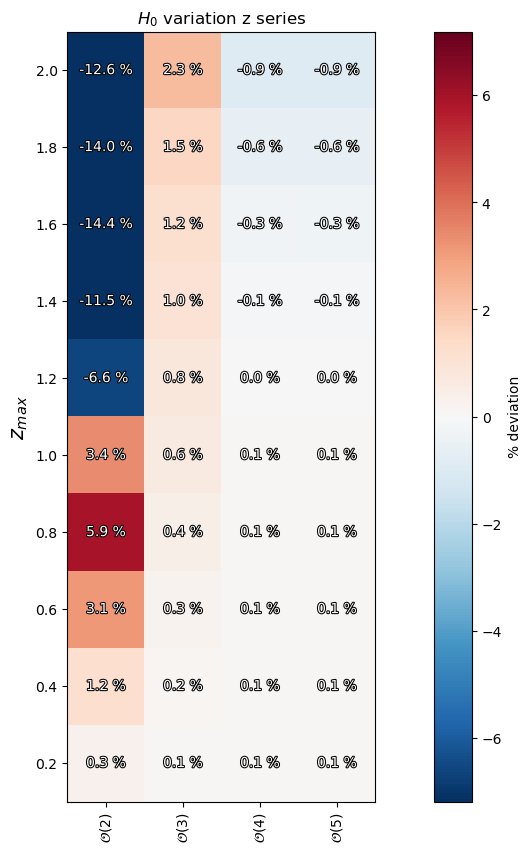

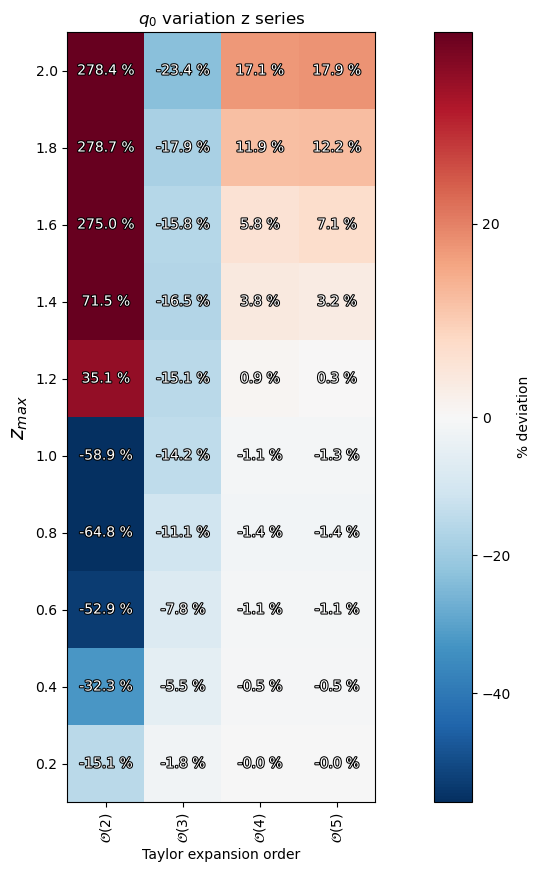

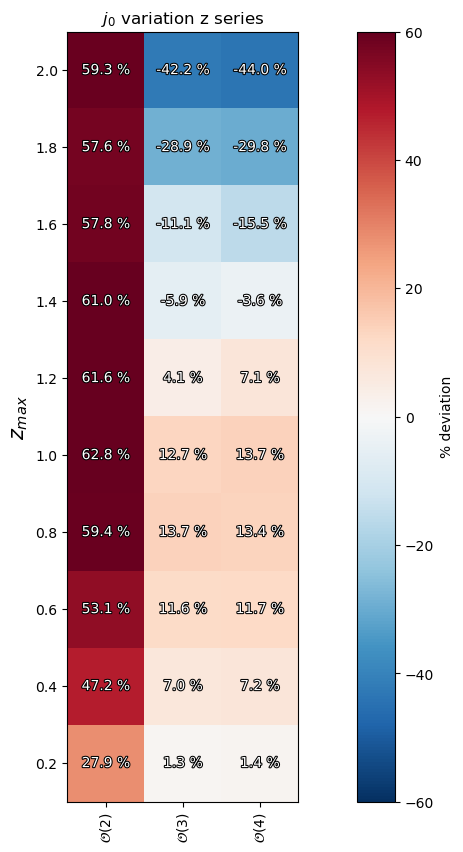

In [13]:
matrix_plot_2('z series',H0_all_err_med[0], q0_all_err_med[0], j0_all_err_med[0])

In [ ]:
matrix_plot_2('Pade 21',H0_all_median[3], q0_all_median[3], j0_all_median[3], ordermin=1)

In [ ]:
matrix_plot_2('Pade 22',H0_all_median[4], q0_all_median[4],j0_all_median[4], ordermin=2)

In [ ]:
matrix_plot_2('Pade 32',H0_all_median[5], q0_all_median[5], j0_all_median[5],ordermin=3)

In [ ]:
matrix_plot_2('log series', H0_all_median[1], q0_all_median[1], j0_all_median[1],ordermin=0)

# Calculating Om errors

In [ ]:
def to_cosmology(q0, j0=1, k=0, W=-1):
    if W == -1:
        if k == 0:
            Om = 2/3 * (q0 + 1)
            return Om
        else:
            Om = 2/3 * (q0 + j0)
            Ok = 1 - j0
            return Om, Ok
    else:
        Om = (2*(j0 - q0 - 2*q0**2))/(1 + 2*j0 - 6*q0)
        Ok = 0
        w = (-1 - 2*j0 + 6*q0)/(3 - 6*q0)        
        return Om, Ok, w

In [ ]:
# Creating par_err arrays for each order
N_runs = 1000
N_z = 10

N_fun = 4 
Om_err_2 = np.zeros((N_z, N_fun -1 , N_runs))
for i in range(len(min_z.iloc[0,0])):
    for k in range(len(q0_est_2[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            Om_err_2[i, k, j] = (100*( to_cosmology(q0_est_2)[i, k+1, j] - to_cosmology(q0_est_2)[i, 0, j])/(abs(to_cosmology(q0_est_2)[i, 0, j])))



N_fun = 5 
Om_err_3 = np.zeros((N_z, N_fun -1 , N_runs))
for i in range(len(min_z.iloc[0,0])):
    for k in range(len(q0_est_3[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            Om_err_3[i, k, j] = (100*( to_cosmology(q0_est_3)[i, k+1, j] - to_cosmology(q0_est_3)[i, 0, j])/(abs(to_cosmology(q0_est_3)[i, 0, j])))


N_fun = 6
Om_err_4 = np.zeros((N_z, N_fun -1 , N_runs))
for i in range(len(min_z.iloc[0,0])):
    for k in range(len(q0_est_4[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            Om_err_4[i, k, j] = (100*( to_cosmology(q0_est_4)[i, k+1, j] - to_cosmology(q0_est_4)[i, 0, j])/(abs(to_cosmology(q0_est_4)[i, 0, j])))

N_fun = 7
Om_err_5 = np.zeros((N_z, N_fun -1 , N_runs))
for i in range(len(min_z.iloc[0,0])):
    for k in range(len(q0_est_5[0])-1):
        for j in range(len(min_z.iloc[0,0][0])):
            Om_err_5[i, k, j] = (100*( to_cosmology(q0_est_5)[i, k+1, j] - to_cosmology(q0_est_5)[i, 0, j])/(abs(to_cosmology(q0_est_5)[i, 0, j])))

In [ ]:
Om_err_all = (Om_err_2, Om_err_3, Om_err_4, Om_err_5)
Om_list = []

Om_all_median = np.full((6, 10, 4), np.nan)

for o in range(4):
    for z in range(N_z):
        for f in range(len(Om_err_all[o][0])):
            for j in range(len(Om_err_all[o][9-z][0])):
                notnan = ~np.isnan(Om_err_all[o][9-z][f])
                Om_err_clean = Om_err_all[o][9-z][f][notnan]
                Om_all_median[f][z][o] = np.median(Om_err_clean)
                Om_list.append(np.median(Om_err_clean))

In [ ]:
# Flatten the inhomogeneous array
flattened_Om = np.concatenate([np.ravel(a) for a in Om_list])
# flattened_q0 = np.concatenate([np.ravel(a) for a in q0_list])
# flattened_j0 = np.concatenate([np.ravel(a) for a in j0_list])

# Get the maximum value
Om_max = np.max(flattened_Om)
Om_min = np.min(flattened_Om)
Om_lim = max(abs(Om_min), abs(Om_max))

Om_max, Om_min, Om_lim

In [ ]:
def matrix_plot_Om(title , Om_err_x, ordermin=0):

    Om_err = np.zeros((10, 4 - ordermin))
    notnan = ~np.isnan(Om_err_x[0])
    
    for i in range(N):
        Om_err[i] = Om_err_x[i][notnan]  

    labels = []
    for j in range(4-ordermin):
        labels.append('$\mathcal{O}(' + str(j+2 +ordermin) + ')$')

    # H0 plot
    plt.figure(figsize=(15,10))
    plt.title('$O_m$ variation '+str(title))
    lst = [Om_err.min(), 0, Om_err.max()]
    is_increasing = all(lst[i] < lst[i + 1] for i in range(len(lst) - 1))
    
    # # Determine color normalization
    # if is_increasing:
    #     vmin = Om_err.min()
    #     vcenter = 0
    #     vmax = Om_err.max()
    #     norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    #     cmap = plt.get_cmap('RdBu')
    # elif H0_err.min()>0:
    #     vmin = Om_err.min()
    #     vmax = Om_err.max()
    #     norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    #     cmap = plt.get_cmap('Reds')
    # else:
    #     vmin = Om_err.max()
    #     vmax = Om_err.min()
    #     norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    #     cmap = plt.get_cmap('Blues_r')

    if is_increasing:
        vmin = -Om_lim/8 #q0_err.min()
        vcenter = 0
        vmax = Om_lim/8
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        cmap = plt.get_cmap('RdBu_r')
    elif Om_err.min()>0:
        vmin = 0#q0_err.min()
        vmax = Om_lim/8
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Reds')
    else:
        vmin = -Om_lim/8
        vmax = 0 #q0_err.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('Blues_r')

    
    plt.imshow(Om_err,norm=norm,cmap=cmap)#olor_map) ##matrix plot 
    y_ticks=[i for i in range(int(N))]
    y_labels=np.round(np.linspace(ZMAX,0.2,int(N)),1)
    x_ticks = np.arange(0,4 - ordermin,1)# [0, 1, 2, 3] 
    plt.ylabel('$z_{max}$',fontsize=15)
    
    x_labels = labels
    plt.xticks(x_ticks, x_labels, rotation ='vertical') 
    plt.yticks(y_ticks, y_labels) 
    plt.colorbar(label='% deviation')
    ## for annotating on the plot
    for i in range(Om_err.shape[0]):
        for j in range(Om_err.shape[1]):
            text = plt.text(j, i, f'{Om_err[i, j]:.1f} %',
                        ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)
    plt.show() 

# Visualizing Om errors

In [ ]:
matrix_plot_Om('z series', Om_all_median[0]), matrix_plot_Om('log series', Om_all_median[1]), matrix_plot_Om('y series', Om_all_median[2])

# d_l error vs q_est_error

In [ ]:
ordermin = 0

H0_err = np.zeros((10, 4 - ordermin))
q0_err = np.zeros((10, 4 - ordermin))
notnan = ~np.isnan(H0_all_median[0][0])
#H0_err [func][z][order]
for i in range(N):
    H0_err[i] = H0_all_median[0][i][notnan]  
    q0_err[i] = q0_all_median[0][i][notnan]

In [ ]:
H0_err_all = (H0_err_2, H0_err_3, H0_err_4, H0_err_5)
q0_err_all = (q0_err_2, q0_err_3, q0_err_4, q0_err_5)
j0_err_all = (j0_err_3, j0_err_4, j0_err_5)
H0_list = []
q0_list = []
j0_list = []


H0_all_err_med = np.full((6, 10, 4), np.nan)
q0_all_err_med = np.full((6, 10, 4), np.nan)
j0_all_err_med = np.full((6, 10, 3), np.nan)

for o in range(4):
    for z in range(N_z):
        for f in range(len(H0_err_all[o][0])):
            notnan = ~np.isnan(H0_err_all[o][z][f])
            H0_err_clean = H0_err_all[o][z][f][notnan]
            q0_err_clean = q0_err_all[o][z][f][notnan]
            H0_all_err_med[f][z][o] = np.median(H0_err_clean)
            q0_all_err_med[f][z][o] = np.median(q0_err_clean)
            H0_list.append(np.median(H0_err_clean))
            q0_list.append(np.median(q0_err_clean))

for o in range(3):
    for z in range(N_z):
        for f in range(len(j0_err_all[o][0])):
            notnan = ~np.isnan(j0_err_all[o][z][f])
            j0_err_clean = j0_err_all[o][z][f][notnan]
            j0_all_err_med[f][z][o] = np.median(j0_err_clean)
            j0_list.append(np.median(j0_err_clean))

100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 152.33it/s]


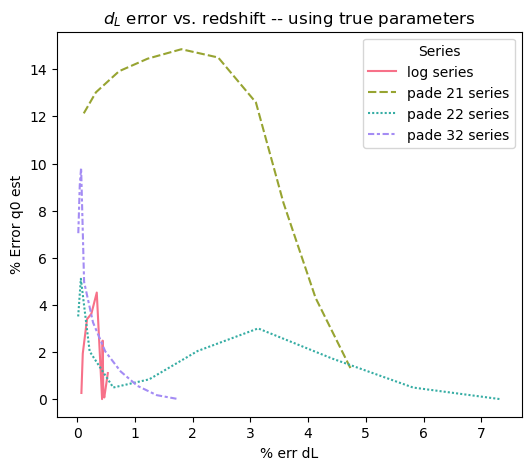

In [11]:
Ok = 0.01
w = -1
N=10

# Define the range of zmax values
z_max_array = np.linspace(0.2, 2, N)

err_dLz = np.zeros((10))
err_dLlog = np.zeros((10))
err_dLy = np.zeros((10))
err_dLpade22 = np.zeros((10))
err_dLpade21 = np.zeros((10))
err_dLpade32 = np.zeros((10))
err_dLpade42 = np.zeros((10))

 # Loop over z_max_array
for idx, zmax in enumerate(tqdm(z_max_array)):
    
    H0 = H0_all_est_med[0][idx][2]
    Om = to_cosmology(q0_all_est_med[0][idx][2])
    zs = np.arange(0.0008, zmax, 0.005)
    my_cosmo = cosmo.wCDM(H0=H0, Om0=Om, Ode0=1.0-Om-Ok)
    dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

    H0p = to_cosmographic(H0, Om,Ok,w=-1)[0]
    q0p = to_cosmographic(H0, Om,Ok,-1)[1]
    j0p = to_cosmographic(H0, Om,Ok,-1)[2]
    s0p = to_cosmographic(H0, Om,Ok,-1)[3]
    c0p = to_cosmographic(H0, Om,Ok,-1)[4]
    p0p = to_cosmographic(H0, Om,Ok,-1)[5]


    ys = zs/(1+zs)
    err_dLpade22[idx] = 100*abs(dLpade22(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0)[-1] - dls_true[-1])/dls_true[-1]
    err_dLpade21[idx] = 100*abs(dLpade21(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0)[-1] - dls_true[-1])/dls_true[-1]
    err_dLpade32[idx] = 100*abs(dLpade32(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0)[-1] - dls_true[-1])/dls_true[-1]
    err_dLpade42[idx] = 100*abs(dLpade42(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0)[-1] - dls_true[-1])/dls_true[-1]
    # err_pade51 = 100*abs(dLpade51(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
    err_dLz[idx] = 100*abs(z_series(zs, H0p, q0p, j0p, s0p,c0p, p0p, order = 4)[-1] - dls_true[-1])/dls_true[-1]
    err_dLy[idx] = 100*abs(y_series(ys, H0p, q0p, j0p, s0p,c0p, p0p, order = 4)[-1] - dls_true[-1])/dls_true[-1]
    err_dLlog[idx] = 100*abs(log_series(np.log(1+zs), H0p, q0p, j0p, s0p, c0p,p0p,order= 4)[-1] - dls_true[-1])/dls_true[-1]
    # err_padeaverage = 100*abs(dLpadeaverage(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true


# # Prepare the data in long form
# data_corr = pd.DataFrame({
#     'err_dL':list(err_dLz) + list(err_dLlog) + list(err_dLpade21) + list(err_dLpade22) + list(err_dLpade32), #+ list(err_dLy) + list(err_dLpade42),
#     'err_q0_est': list(abs(q0_all_err_med[0, :, 2])) + list(abs(q0_all_err_med[1, :, 2]))+ list(abs(q0_all_err_med[3, :, 3])) + list(abs(q0_all_err_med[4, :, 3])) + list(abs(q0_all_err_med[5, :, 3])),#+ list(abs(q0_all_err_med[2, :, 2]))
#     'Series': ['z series'] * N + ['log series'] * N  + ['pade 21 series'] * N+ ['pade 22 series'] * N
#      + ['pade 32 series'] * N  #+ ['y series'] * N + ['pade 42 series'] * N
# })

# Prepare the data in long form
data_corr = pd.DataFrame({
    'err_dL': list(err_dLlog) + list(err_dLpade21) + list(err_dLpade22) + list(err_dLpade32), #+ list(err_dLy) + list(err_dLpade42),
    'err_q0_est':  list(abs(q0_all_err_med[1, :, 2]))+ list(abs(q0_all_err_med[3, :, 3])) + list(abs(q0_all_err_med[4, :, 3])) + list(abs(q0_all_err_med[5, :, 3])),#+ list(abs(q0_all_err_med[2, :, 2]))
    'Series':  ['log series'] * N  + ['pade 21 series'] * N+ ['pade 22 series'] * N
     + ['pade 32 series'] * N  #+ ['y series'] * N + ['pade 42 series'] * N
})


# Plot with hue and palette
plt.figure(figsize=(6, 5))
sns.lineplot(data=data_corr, x='err_dL', y='err_q0_est', hue='Series', style="Series",  palette='husl')
#plt.ylim(0,50)
plt.xlabel('% err dL')
plt.ylabel('% Error q0 est')
plt.title('$d_L$ error vs. redshift -- using true parameters')

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()

# Relation between dL_error with perfect parameters and error in the real parameter estimation

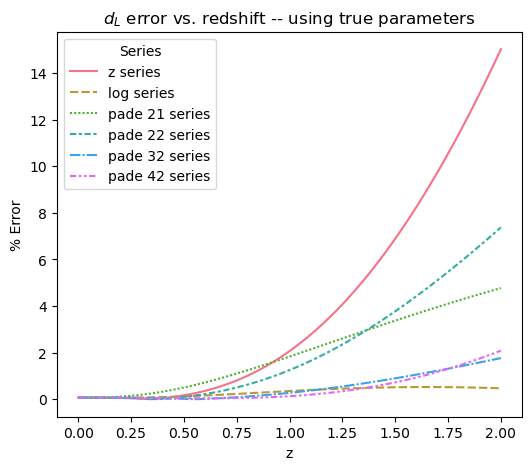

In [12]:
H0 = 73.8
Om = 0.3
Ok = 0.01
w = -1

zs = np.linspace(0.0001, 2, 100)
my_cosmo = cosmo.wCDM(H0=H0, Om0=Om, Ode0=1.0-Om-Ok)
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value

H0p = to_cosmographic(H0, Om,Ok,w=-1)[0]
q0p = to_cosmographic(H0, Om,Ok,-1)[1]
j0p = to_cosmographic(H0, Om,Ok,-1)[2]
s0p = to_cosmographic(H0, Om,Ok,-1)[3]
c0p = to_cosmographic(H0, Om,Ok,-1)[4]
p0p = to_cosmographic(H0, Om,Ok,-1)[5]


ys = zs/(1+zs)
err_pade22 = 100*abs(dLpade22(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade21 = 100*abs(dLpade21(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade32 = 100*abs(dLpade32(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade42 = 100*abs(dLpade42(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_pade51 = 100*abs(dLpade51(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true
err_z = 100*abs(z_series(zs, H0p, q0p, j0p, s0p,c0p, p0p, order = 4) - dls_true)/dls_true
err_y = 100*abs(y_series(ys, H0p, q0p, j0p, s0p,c0p, p0p, order = 4) - dls_true)/dls_true
err_log = 100*abs(log_series(np.log(1+zs), H0p, q0p, j0p, s0p, c0p,p0p,order= 4) - dls_true)/dls_true
err_padeaverage = 100*abs(dLpadeaverage(zs, H0p, q0p, j0p, s0p, c0p, p0p,order= 0) - dls_true)/dls_true


# Prepare the data in long form
data_p = pd.DataFrame({
    'zs': list(zs) * 6,
    'Difference': list(err_z) + list(err_log)+ list(err_pade21)+ list(err_pade22) + list(err_pade32) + list(err_pade42),
    'Series': ['z series'] * len(zs) + ['log series'] * len(zs) + ['pade 21 series'] * len(zs)+ ['pade 22 series'] * len(zs)
     + ['pade 32 series'] * len(zs)  + ['pade 42 series'] * len(zs)
})


# Plot with hue and palette
plt.figure(figsize=(6, 5))
sns.lineplot(x='zs', y='Difference', hue='Series', style="Series", data=data_p, palette='husl')
#plt.ylim(0,50)
plt.xlabel('z')
plt.ylabel('% Error')
plt.title('$d_L$ error vs. redshift -- using true parameters')

# Save the figure as a PNG, PDF, or JPEG
#plt.savefig('dL_error_perfect_params_z5.png', dpi=500,  bbox_inches='tight')  # To save as PNG
plt.show()